# CardioIA · Fase 2 · Parte 2: Classificador de risco

**Objetivo:** ler a frase de um paciente e classificar como **alto risco** ou **baixo risco**, simulando uma triagem automática.

**Fluxo:** frase do paciente → TF-IDF (texto vira números) → Regressão Logística → alto ou baixo risco.

> Projeto acadêmico. Todas as frases são inventadas e os rótulos não foram revisados por médico. Não é ferramenta de diagnóstico.

## Critério de rotulagem

- **alto risco:** dor ou aperto no peito forte, prolongado ou que surge com esforço; dor que irradia para braço, mandíbula, pescoço ou costas; falta de ar em repouso ou ao deitar; desmaio ou quase desmaio; palpitação com tontura, dor ou falta de ar; sintoma novo e intenso que impede a rotina.
- **baixo risco:** sintoma leve e passageiro, com causa aparente (exercício pesado, refeição pesada, café, ansiedade pontual, má postura), sem sinal de alarme e sem prejuízo importante da rotina.
- **desempate:** se houver qualquer sinal de alarme, a frase é alto risco.

## 1. Bibliotecas

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, confusion_matrix, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

## 2. Carregar e conferir o dataset

O CSV tem duas colunas: `frase` e `situacao`. As conferências abaixo garantem que o dataset está balanceado, sem duplicatas, só com os dois rótulos e **sem a frase do vídeo** (se ela estivesse no treino, o modelo só "lembraria" dela).

In [2]:
# Funciona rodando de dentro da pasta parte2_classificador/ ou da raiz do repositório
CAMINHO = Path("frases_risco.csv")
if not CAMINHO.exists():
    CAMINHO = Path("parte2_classificador") / "frases_risco.csv"

df = pd.read_csv(CAMINHO, encoding="utf-8")

FRASE_VIDEO = "Há dois dias sinto um aperto no peito que vai pro braço quando subo escada."

print("Total de frases:", len(df))
print(df["situacao"].value_counts(), "\n")
assert set(df["situacao"]) == {"alto risco", "baixo risco"}, "rótulo fora do padrão"
assert not df["frase"].duplicated().any(), "frase duplicada"
assert FRASE_VIDEO.lower() not in df["frase"].str.lower().tolist(), "frase do vídeo está no dataset"
print("Conferências ok.")
df.sample(5, random_state=1)

Total de frases: 150
situacao
alto risco     75
baixo risco    75
Name: count, dtype: int64 

Conferências ok.


,frase,situacao
14,o peito dói muito quando respiro fundo e estou...,alto risco
98,estou um pouco cansado depois de voltar a trei...,baixo risco
75,tive um leve incômodo nas costas depois de car...,baixo risco
16,qualquer esforço me deixa sem ar e com o peito...,alto risco
131,meu peito dói um pouco depois de fazer flexões...,baixo risco


## 3. TF-IDF + modelo

**TF-IDF, em uma frase:** dá peso alto às palavras que aparecem numa frase mas são raras no resto do dataset. Palavras que diferenciam (como "irradia" ou "desmaiei") valem mais que palavras comuns (como "sinto").

| Escolha | Por quê |
|---|---|
| `test_size=0.25` | 75% para aprender, 25% para testar (≈38 frases de teste). |
| `stratify` | Mesma proporção alto/baixo no treino e no teste. |
| `random_state=42` | Resultado reproduzível. A P3 usa os mesmos valores para comparar modelos. |
| `ngram_range=(1, 2)` | Considera pares de palavras: "falta de", "dor forte", "não sinto". |
| `strip_accents="unicode"` | "tórax" e "torax" viram a mesma palavra. |
| `Pipeline` | O TF-IDF aprende o vocabulário só com o treino, sem "espiar" o teste (evita vazamento). |
| Regressão Logística | Funciona bem com muitas colunas e poucas frases, é rápida e mostra o peso de cada palavra. |
| Sem stopwords | Listas prontas removem "não" e "sem", e "sem dor" é muito diferente de "dor". |

In [3]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    df["frase"], df["situacao"], test_size=0.25, stratify=df["situacao"], random_state=42)

modelo = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), strip_accents="unicode")),
    ("clf", LogisticRegression()),
])
modelo.fit(X_treino, y_treino)

print("Frases de treino:", len(X_treino), "| frases de teste:", len(X_teste))
print("Tamanho do vocabulário (palavras + pares):", len(modelo.named_steps["tfidf"].vocabulary_))

Frases de treino: 112 | frases de teste: 38
Tamanho do vocabulário (palavras + pares): 1096


## 4. Avaliação

A acurácia é pedida no enunciado, mas sozinha não basta. Numa triagem, o erro grave é o **falso negativo**: classificar como baixo risco um caso de alto risco, o que manda o paciente grave para o fim da fila. Por isso olhamos também o **recall de "alto risco"**: de todos os casos graves do teste, quantos o modelo pegou.

In [4]:
y_pred = modelo.predict(X_teste)

acuracia = accuracy_score(y_teste, y_pred)
recall_alto = recall_score(y_teste, y_pred, pos_label="alto risco")
print(f"Acurácia: {acuracia:.3f}")
print(f"Recall de 'alto risco': {recall_alto:.3f}\n")
print(classification_report(y_teste, y_pred, digits=3))

Acurácia: 0.868
Recall de 'alto risco': 0.895

              precision    recall  f1-score   support

  alto risco      0.850     0.895     0.872        19
 baixo risco      0.889     0.842     0.865        19

    accuracy                          0.868        38
   macro avg      0.869     0.868     0.868        38
weighted avg      0.869     0.868     0.868        38



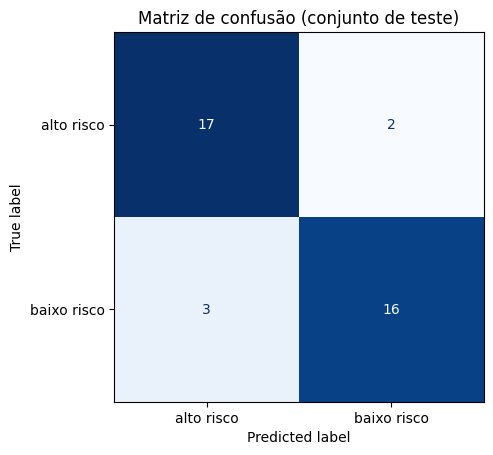

Falsos negativos (alto classificado como baixo): 2
Falsos positivos (baixo classificado como alto): 3


In [5]:
ROTULOS = ["alto risco", "baixo risco"]
cm = confusion_matrix(y_teste, y_pred, labels=ROTULOS)
ConfusionMatrixDisplay(cm, display_labels=ROTULOS).plot(cmap="Blues", colorbar=False)
plt.title("Matriz de confusão (conjunto de teste)")
plt.show()

print("Falsos negativos (alto classificado como baixo):", cm[0, 1])
print("Falsos positivos (baixo classificado como alto):", cm[1, 0])

### Frases que o modelo errou no teste

In [6]:
erros = pd.DataFrame({"frase": X_teste, "real": y_teste, "previsto": y_pred})
erros = erros[erros["real"] != erros["previsto"]]
print(f"{len(erros)} erro(s) em {len(X_teste)} frases de teste")
erros

5 erro(s) em 38 frases de teste


,frase,real,previsto
139,tô meio cansado porque dormi mal essa noite,baixo risco,alto risco
2,desmaiei hoje de manhã enquanto tomava banho,alto risco,baixo risco
37,perdi a consciência por um momento enquanto co...,alto risco,baixo risco
134,o coração disparou quando levei um susto com o...,baixo risco,alto risco
85,"o peito dói quando aperto o local, desde que b...",baixo risco,alto risco


## 5. O que o modelo aprendeu

Os pesos da Regressão Logística mostram as palavras (e pares de palavras) que mais puxam a frase para cada lado. É uma forma simples de explicar a decisão do modelo. A análise de vieses a fundo fica com a P3, em `avaliacao_e_vieses.py`.

In [7]:
vocab = modelo.named_steps["tfidf"].get_feature_names_out()
pesos = modelo.named_steps["clf"].coef_[0]
classe_positiva = modelo.named_steps["clf"].classes_[1]   # peso positivo puxa para esta classe

ordem = np.argsort(pesos)
outra = [c for c in modelo.classes_ if c != classe_positiva][0]
tabela = pd.DataFrame({
    f"puxa para '{outra}'": vocab[ordem[:10]],
    f"peso ({outra})": pesos[ordem[:10]].round(2),
    f"puxa para '{classe_positiva}'": vocab[ordem[::-1][:10]],
    f"peso ({classe_positiva})": pesos[ordem[::-1][:10]].round(2),
})
tabela

,puxa para 'alto risco',peso (alto risco),puxa para 'baixo risco',peso (baixo risco)
0,peito,-0.74,depois,1.16
1,forte,-0.60,de,1.05
2,no peito,-0.58,depois de,1.02
3,dor no,-0.45,leve,0.71
4,que,-0.43,pouco,0.57
5,ar,-0.40,um,0.54
6,com dor,-0.38,um pouco,0.52
7,ha,-0.34,passou,0.44
8,dor,-0.34,tenho,0.42
9,para,-0.34,ao,0.40


## 6. Frases novas

Frases escritas na hora, fora do dataset, para ver como o modelo reage a riscos diferentes. A primeira é a frase do paciente do vídeo.

In [8]:
frases_novas = [
    FRASE_VIDEO,
    "Fiquei um pouco cansado depois de jogar vôlei na praia, mas já estou bem.",
    "Do nada senti uma dor muito forte no peito e quase desmaiei no ônibus.",
    "Não sinto dor no peito, só estou com o nariz escorrendo.",
    "Estou com uma gastura no peito e o braço meio esquisito desde cedo.",
]
proba = modelo.predict_proba(frases_novas)
idx_alto = list(modelo.classes_).index("alto risco")
pd.DataFrame({
    "frase": frases_novas,
    "previsão": modelo.predict(frases_novas),
    "prob. alto risco": proba[:, idx_alto].round(2),
})

,frase,previsão,prob. alto risco
0,Há dois dias sinto um aperto no peito que vai ...,alto risco,0.59
1,Fiquei um pouco cansado depois de jogar vôlei ...,baixo risco,0.24
2,Do nada senti uma dor muito forte no peito e q...,alto risco,0.64
3,"Não sinto dor no peito, só estou com o nariz e...",alto risco,0.56
4,Estou com uma gastura no peito e o braço meio ...,alto risco,0.66


## 7. Padrões e distorções observadas

1. **O modelo aprendeu "dor no peito = grave", não "sinal de alarme = grave".** As palavras que mais puxam para alto risco são *peito*, *forte*, *no peito* e *dor no*. Os 2 falsos negativos do teste são justamente casos de desmaio sem dor no peito ("desmaiei hoje de manhã enquanto tomava banho" e "perdi a consciência por um momento enquanto conversava"). Desmaio é sinal de alarme pelo nosso critério, mas aparece em poucas frases do dataset, então pesa pouco.
2. **Palavras sem sentido clínico estão pesando.** Os maiores pesos para baixo risco são *depois* (1,16), *de* (1,05) e *depois de* (1,02), à frente de palavras com sentido real, como *leve* e *passou*. Isso acontece porque, ao escrever as frases de baixo risco, colocamos uma causa aparente ("depois de comer", "depois do treino"). O modelo aprendeu o nosso jeito de escrever, não a medicina: uma frase grave que use "depois" tende a ser puxada para baixo risco.
3. **Negação não funciona.** "Não sinto dor no peito, só estou com o nariz escorrendo" foi classificada como alto risco (0,56). O TF-IDF vê *dor no peito* e quase não tem exemplos de negação para aprender o contrário.
4. **Falsos positivos por palavra-chave.** As 3 frases de baixo risco classificadas como alto têm *coração disparou*, *peito* ou *cansado*, mesmo com causa clara (susto, pancada, noite mal dormida). O modelo olha a palavra e ignora o contexto.
5. **Pouca confiança.** Nas frases novas, as probabilidades ficaram entre 0,24 e 0,66. A frase do vídeo acertou (alto risco), mas com 0,59, pouco acima do limite de 0,5. Com 112 frases de treino, o modelo separa os casos óbvios, mas não tem margem nos ambíguos.

**Resumo:** acurácia de 86,8% e recall de alto risco de 89,5% (2 casos graves perdidos em 19). Os números são otimistas, porque treino e teste foram escritos pelas mesmas pessoas, com o mesmo vocabulário. O teste com frases cegas da P3 mede o desempenho de forma mais honesta. Como triagem, o modelo pode **priorizar** casos, mas a decisão final é sempre do profissional de saúde.